# Access to Care: Opioid Overdose Risk & Treatment Availability
### Capstone Analysis Notebook

This notebook answers four research questions using county-level data from CDC WONDER, SAMHSA, and the U.S. Census Bureau ACS (2018–2024).

**Research Questions:**
1. How do socioeconomic factors (income, poverty, unemployment) correlate with opioid overdose mortality rates?
2. Are treatment facilities distributed in proportion to overdose mortality rates?
3. Does treatment access correlate with lower overdose mortality?
4. Which counties show the largest gaps between overdose risk and treatment availability?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

In [3]:
#set a theme for all visuals
sns.set_theme(style='whitegrid', font_scale=1.15)
PALETTE  = 'viridis'
ACCENT   = '#2c7bb6'
WARN     = '#d7191c'
FIG_SIZE = (10, 6)

In [5]:
df = pd.read_csv('../data/master_df.csv')
df.head()

,county_state,fips,deaths,Population,median_income,population,poverty_rate,unemployment_rate,facility_count,overdose_rate,facility_rate
0,"Abbeville County, SC",45001.0,45.0,171168,52935.0,24420.0,15.7,4.0,NaN,184.275184,NaN
1,"Acadia Parish, LA",22001.0,151.0,413278,45562.0,56955.0,25.0,7.7,1.0,265.121587,1.755772
2,"Accomack County, VA",51001.0,55.0,230053,58993.0,33335.0,13.9,3.4,2.0,164.991750,5.999700
3,"Ada County, ID",16001.0,676.0,3537262,91502.0,518935.0,8.3,3.1,36.0,130.266796,6.937285
4,"Adair County, IA",0.0,NaN,NaN,68092.0,7460.0,9.5,4.0,NaN,NaN,NaN


In [6]:
# Rename duplicate population columns 
df = df.rename(columns={
    'Population': 'population_7yr',   # cumulative 7-year CDC denominator
    'population': 'population'        # single-year population
})

# Drop territory rows with bad FIPS
df = df[df['fips'] != '00000'].copy()

# Extract state 
df['state'] = df['county_state'].str.extract(r',\s*([A-Z]{2})$')

# gap score (used in Q4)
df['gap_score'] = df['overdose_rate'] - df['facility_rate']

# Working subset: rows with all analytical columns present
cols_needed = ['overdose_rate', 'poverty_rate', 'median_income',
               'unemployment_rate', 'facility_rate', 'facility_count', 'gap_score']
complete = df.dropna(subset=cols_needed).copy()

print(f'Total counties: {len(df):,}')
print(f'Complete rows for analysis: {len(complete):,}')
df.head(3)

Total counties: 3,314
Complete rows for analysis: 1,887


,county_state,fips,deaths,population_7yr,median_income,population,poverty_rate,unemployment_rate,facility_count,overdose_rate,facility_rate,state,gap_score
0,"Abbeville County, SC",45001.0,45.0,171168,52935.0,24420.0,15.7,4.0,NaN,184.275184,NaN,SC,NaN
1,"Acadia Parish, LA",22001.0,151.0,413278,45562.0,56955.0,25.0,7.7,1.0,265.121587,1.755772,LA,263.365815
2,"Accomack County, VA",51001.0,55.0,230053,58993.0,33335.0,13.9,3.4,2.0,164.991750,5.999700,VA,158.992050


---
## Q1 — How do socioeconomic factors correlate with opioid overdose mortality?

We examine three socioeconomic variables — median household income, poverty rate, and unemployment rate — against the county-level overdose rate (per 100k, age-adjusted). We use both a correlation heatmap and individual scatter plots with regression lines.

In [7]:
corr_cols = {
    'overdose_rate':    'Overdose Rate',
    'median_income':    'Median Income',
    'poverty_rate':     'Poverty Rate',
    'unemployment_rate':'Unemployment Rate',
    'facility_rate':    'Facility Rate',
    'gap_score':        'Gap Score'
}

In [8]:
corr_df = complete[list(corr_cols.keys())].rename(columns=corr_cols)
corr_matrix = corr_df.corr()

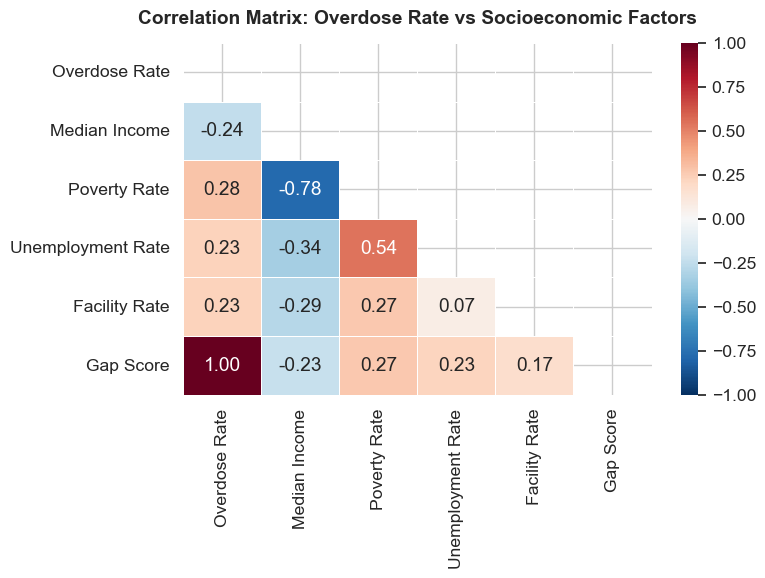

Saved: q1_correlation_heatmap.png


In [9]:
fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # hide upper triangle

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True, fmt='.2f',
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    linewidths=0.5,
    ax=ax
)
ax.set_title('Correlation Matrix: Overdose Rate vs Socioeconomic Factors', pad=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/q1_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: q1_correlation_heatmap.png')

In [10]:
socio_vars = [
    ('median_income',     'Median Household Income ($)',  False),
    ('poverty_rate',      'Poverty Rate (%)',              True),
    ('unemployment_rate', 'Unemployment Rate (%)',         True),
]

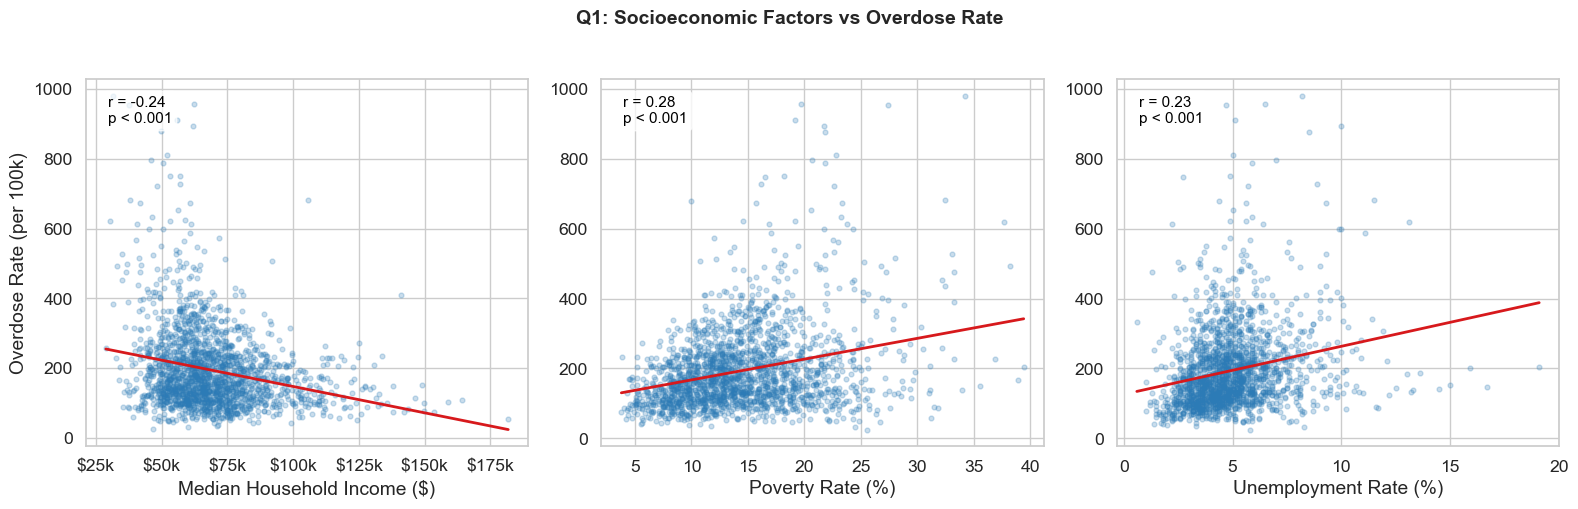

Saved: q1_socioeconomic_scatter.png


In [22]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Q1: Socioeconomic Factors vs Overdose Rate', fontsize=14, fontweight='bold', y=1.02)

for ax, (col, label, positive_expected) in zip(axes, socio_vars):
    x = complete[col]
    y = complete['overdose_rate']

    # Scatter
    ax.scatter(x, y, alpha=0.25, s=12, color=ACCENT)

    # Regression line
    m, b, r, p, _ = stats.linregress(x, y)
    x_line = np.linspace(x.min(), x.max(), 200)
    ax.plot(x_line, m * x_line + b, color=WARN, linewidth=2)

    # Annotate with r and p-value
    p_str = f'p < 0.001' if p < 0.001 else f'p = {p:.3f}'
    ax.annotate(f'r = {r:.2f}\n{p_str}',
                xy=(0.05, 0.88), xycoords='axes fraction',
                fontsize=11, color='black',
                bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.7))

    ax.set_xlabel(label)
    ax.set_ylabel('Overdose Rate (per 100k)' if ax == axes[0] else '')

    # Format x-axis for income
    if col == 'median_income':
        ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'${v/1000:.0f}k'))

plt.tight_layout()
plt.savefig('../outputs/q1_socioeconomic_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: q1_socioeconomic_scatter.png')

In [13]:
print('Pearson correlations with Overdose Rate:\n')
for col, label, _ in socio_vars:
    r, p = stats.pearsonr(complete[col], complete['overdose_rate'])
    sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else ''))
    print(f'  {label:<30} r = {r:+.3f}  {sig}')

Pearson correlations with Overdose Rate:

  Median Household Income ($)    r = -0.244  ***
  Poverty Rate (%)               r = +0.285  ***
  Unemployment Rate (%)          r = +0.228  ***


## Q2 — Are treatment facilities distributed in proportion to overdose mortality?

If the healthcare system were responding efficiently to need, we'd expect counties with higher overdose rates to also have more treatment facilities per capita. We test this by plotting overdose rate vs facility rate and examining the distribution.

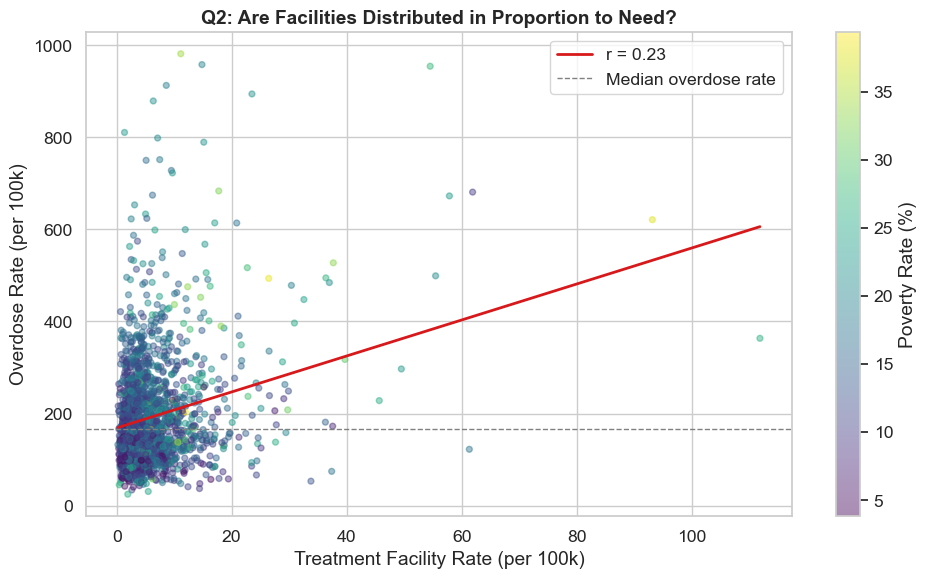

Saved: q2_facility_vs_overdose.png


In [14]:
fig, ax = plt.subplots(figsize=FIG_SIZE)

scatter = ax.scatter(
    complete['facility_rate'],
    complete['overdose_rate'],
    c=complete['poverty_rate'],
    cmap=PALETTE,
    alpha=0.45, s=18
)
plt.colorbar(scatter, ax=ax, label='Poverty Rate (%)')

# Regression
m, b, r, p, _ = stats.linregress(complete['facility_rate'], complete['overdose_rate'])
x_line = np.linspace(complete['facility_rate'].min(), complete['facility_rate'].max(), 200)
ax.plot(x_line, m * x_line + b, color=WARN, linewidth=2, label=f'r = {r:.2f}')

# Reference line: equal supply/demand (facilities proportional to overdose rate)
ax.axhline(complete['overdose_rate'].median(), color='gray', linestyle='--',
           linewidth=1, label='Median overdose rate')

ax.set_xlabel('Treatment Facility Rate (per 100k)')
ax.set_ylabel('Overdose Rate (per 100k)')
ax.set_title('Q2: Are Facilities Distributed in Proportion to Need?', fontweight='bold')
ax.legend()

plt.tight_layout()
plt.savefig('../outputs/q2_facility_vs_overdose.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: q2_facility_vs_overdose.png')

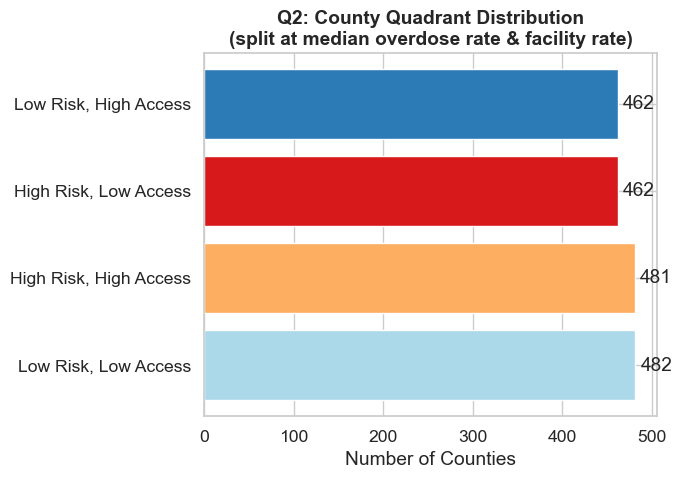


Quadrant counts:
quadrant
Low Risk, Low Access      482
High Risk, High Access    481
High Risk, Low Access     462
Low Risk, High Access     462


In [15]:
# Q2b: Quadrant analysis
# Divide counties into four quadrants by median overdose rate & facility rate
od_med  = complete['overdose_rate'].median()
fac_med = complete['facility_rate'].median()

def quadrant(row):
    hi_od  = row['overdose_rate'] > od_med
    hi_fac = row['facility_rate'] > fac_med
    if hi_od and not hi_fac:  return 'High Risk, Low Access'    # worst
    if hi_od and hi_fac:      return 'High Risk, High Access'
    if not hi_od and hi_fac:  return 'Low Risk, High Access'
    return                           'Low Risk, Low Access'

complete['quadrant'] = complete.apply(quadrant, axis=1)
quad_counts = complete['quadrant'].value_counts()

colors = {
    'High Risk, Low Access':  '#d7191c',
    'High Risk, High Access': '#fdae61',
    'Low Risk, Low Access':   '#abd9e9',
    'Low Risk, High Access':  '#2c7bb6',
}

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.barh(
    quad_counts.index,
    quad_counts.values,
    color=[colors[q] for q in quad_counts.index]
)
ax.bar_label(bars, padding=4)
ax.set_xlabel('Number of Counties')
ax.set_title('Q2: County Quadrant Distribution\n(split at median overdose rate & facility rate)',
             fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/q2_quadrant_chart.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nQuadrant counts:')
print(quad_counts.to_string())

## Q3 — Does treatment access correlate with lower overdose mortality?

We compare overdose rates between counties with above- and below-median facility rates, and use a multivariate regression to control for socioeconomic confounders.

> **Note:** This analysis is correlational, not causal. Counties with more facilities may differ in other ways (urbanicity, income, state policy) that also affect overdose mortality.

/var/folders/h8/51mqc9v517x00_mhcb5s7ncw0000gn/T/ipykernel_2028/4238754014.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


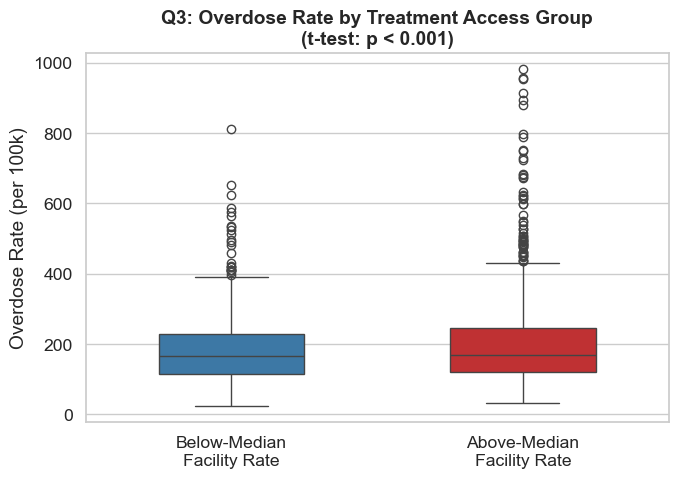

Mean overdose rate — Above-median access: 205.1
Mean overdose rate — Below-median access: 182.6
t = 4.27, p < 0.001


In [16]:
# ── Q3a: Box plot — overdose rate by access group ─────────────────────────
complete['access_group'] = np.where(
    complete['facility_rate'] >= fac_med,
    'Above-Median\nFacility Rate',
    'Below-Median\nFacility Rate'
)

fig, ax = plt.subplots(figsize=(7, 5))
sns.boxplot(
    data=complete,
    x='access_group', y='overdose_rate',
    palette=['#2c7bb6', '#d7191c'],
    width=0.5, ax=ax
)

# T-test
high = complete.loc[complete['access_group'].str.startswith('Above'), 'overdose_rate']
low  = complete.loc[complete['access_group'].str.startswith('Below'), 'overdose_rate']
t, p = stats.ttest_ind(high, low)
p_str = 'p < 0.001' if p < 0.001 else f'p = {p:.3f}'

ax.set_title(f'Q3: Overdose Rate by Treatment Access Group\n(t-test: {p_str})', fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('Overdose Rate (per 100k)')

plt.tight_layout()
plt.savefig('../outputs/q3_access_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Mean overdose rate — Above-median access: {high.mean():.1f}')
print(f'Mean overdose rate — Below-median access: {low.mean():.1f}')
print(f't = {t:.2f}, {p_str}')

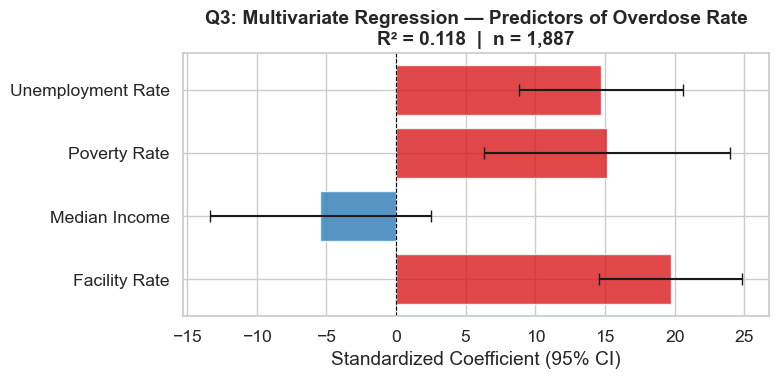

                            OLS Regression Results                            
Dep. Variable:          overdose_rate   R-squared:                       0.118
Model:                            OLS   Adj. R-squared:                  0.116
Method:                 Least Squares   F-statistic:                     62.94
Date:                Sat, 27 Jun 2026   Prob (F-statistic):           5.47e-50
Time:                        13:49:03   Log-Likelihood:                -11509.
No. Observations:                1887   AIC:                         2.303e+04
Df Residuals:                    1882   BIC:                         2.306e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        193.8305      2.484     78.021      0.0

In [17]:
# Q3b: Multivariate OLS regression
# Controls for income, poverty, and unemployment so we can isolate the independent effect of facility access on overdose rate.
try:
    import statsmodels.api as sm
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'statsmodels', '-q'])
    import statsmodels.api as sm

reg_df = complete[['overdose_rate', 'facility_rate', 'median_income',
                    'poverty_rate', 'unemployment_rate']].dropna()

# Standardize predictors so coefficients are comparable
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(reg_df.drop(columns='overdose_rate'))
X = sm.add_constant(X_scaled)
y = reg_df['overdose_rate']

model = sm.OLS(y, X).fit()

# Plot coefficients
coef_names = ['Intercept', 'Facility Rate', 'Median Income',
              'Poverty Rate', 'Unemployment Rate']
coefs  = model.params[1:]   # skip intercept
errors = model.bse[1:]
names  = coef_names[1:]

fig, ax = plt.subplots(figsize=(8, 4))
colors_coef = [WARN if c > 0 else ACCENT for c in coefs]
bars = ax.barh(names, coefs, xerr=errors * 1.96,
               color=colors_coef, alpha=0.8, capsize=4)
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel('Standardized Coefficient (95% CI)')
ax.set_title(f'Q3: Multivariate Regression — Predictors of Overdose Rate\n'
             f'R² = {model.rsquared:.3f}  |  n = {len(y):,}',
             fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/q3_regression_coefs.png', dpi=150, bbox_inches='tight')
plt.show()

print(model.summary())

## Q4 — Which counties show the largest gaps between overdose risk and treatment availability?

We compute a composite risk score and identify the most underserved counties — those where overdose mortality is high relative to treatment access.

In [18]:
# Q4a: Composite risk score 
def normalize(s):
    return (s - s.min()) / (s.max() - s.min())

complete['norm_overdose'] = normalize(complete['overdose_rate'])
complete['norm_poverty']  = normalize(complete['poverty_rate'])
complete['norm_low_fac']  = 1 - normalize(complete['facility_rate'])  # invert: fewer = worse
complete['risk_score']    = (complete['norm_overdose'] +
                              complete['norm_poverty']  +
                              complete['norm_low_fac']) / 3 * 100

top25 = complete.nlargest(25, 'risk_score')[[
    'county_state', 'state', 'risk_score',
    'overdose_rate', 'poverty_rate', 'facility_rate', 'facility_count'
]].reset_index(drop=True)
top25.index += 1
top25.columns = ['County', 'State', 'Risk Score', 'Overdose Rate',
                 'Poverty Rate (%)', 'Facility Rate', 'Facility Count']

print('Top 25 Most At-Risk Counties:')
print(top25.round(2).to_string())

Top 25 Most At-Risk Counties:
                    County State  Risk Score  Overdose Rate  Poverty Rate (%)  Facility Rate  Facility Count
1      McDowell County, WV    WV       91.86         980.88              34.2          11.15             2.0
2       Raleigh County, WV    WV       78.16         810.16              22.8           1.37             1.0
3         Logan County, WV    WV       78.11         878.48              21.8           6.37             2.0
4         Mingo County, WV    WV       77.83         683.17              32.4          17.74             4.0
5       Baltimore city, MD    MD       76.37         957.36              19.7          14.83            85.0
6        Cabell County, WV    WV       76.18         912.24              19.2           8.63             8.0
7        Estill County, KY    KY       74.05         798.00              20.7           7.13             1.0
8      Magoffin County, KY    KY       74.05         493.48              38.2          26.44      

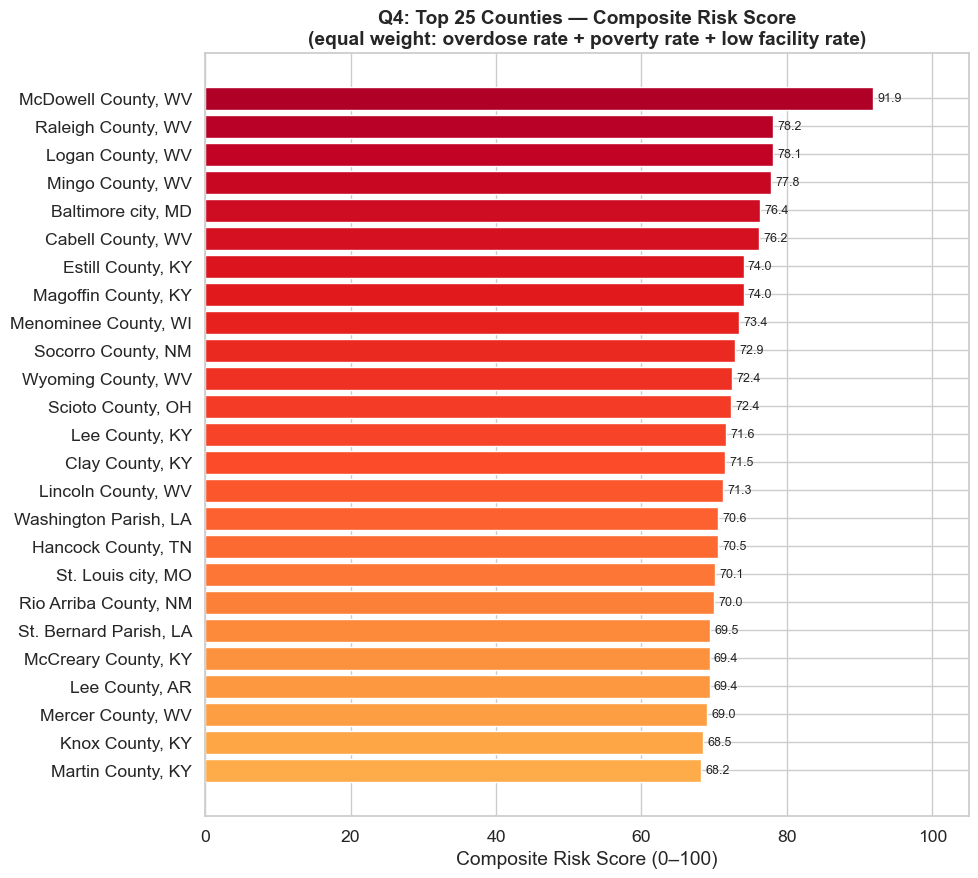

Saved: q4_top25_risk.png


In [19]:
# Q4b: Horizontal bar chart — top 25 at-risk counties
fig, ax = plt.subplots(figsize=(10, 9))

bars = ax.barh(
    top25['County'][::-1],
    top25['Risk Score'][::-1],
    color=plt.cm.YlOrRd(np.linspace(0.4, 0.9, 25))
)
ax.bar_label(bars, fmt='%.1f', padding=3, fontsize=9)
ax.set_xlabel('Composite Risk Score (0–100)')
ax.set_title('Q4: Top 25 Counties — Composite Risk Score\n'
             '(equal weight: overdose rate + poverty rate + low facility rate)',
             fontweight='bold')
ax.set_xlim(0, 105)
plt.tight_layout()
plt.savefig('../outputs/q4_top25_risk.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: q4_top25_risk.png')

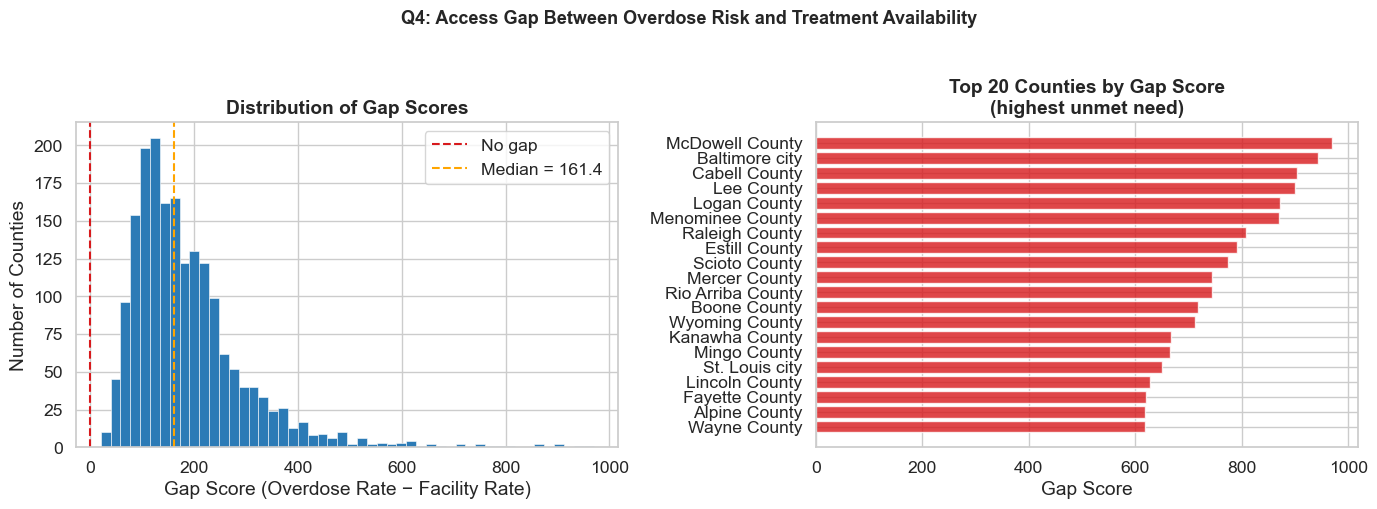

Saved: q4_gap_distribution.png


In [20]:
# Q4c: Gap score distribution — overdose rate minus facility rate 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: histogram of gap scores
axes[0].hist(complete['gap_score'], bins=50, color=ACCENT, edgecolor='white', linewidth=0.4)
axes[0].axvline(0, color=WARN, linewidth=1.5, linestyle='--', label='No gap')
axes[0].axvline(complete['gap_score'].median(), color='orange',
                linewidth=1.5, linestyle='--', label=f'Median = {complete["gap_score"].median():.1f}')
axes[0].set_xlabel('Gap Score (Overdose Rate − Facility Rate)')
axes[0].set_ylabel('Number of Counties')
axes[0].set_title('Distribution of Gap Scores', fontweight='bold')
axes[0].legend()

# Right: top 20 gap score counties
top20_gap = complete.nlargest(20, 'gap_score')
axes[1].barh(
    top20_gap['county_state'].str.replace(r',.*', '', regex=True)[::-1],
    top20_gap['gap_score'][::-1],
    color=WARN, alpha=0.8
)
axes[1].set_xlabel('Gap Score')
axes[1].set_title('Top 20 Counties by Gap Score\n(highest unmet need)', fontweight='bold')

plt.suptitle('Q4: Access Gap Between Overdose Risk and Treatment Availability',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../outputs/q4_gap_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: q4_gap_distribution.png')

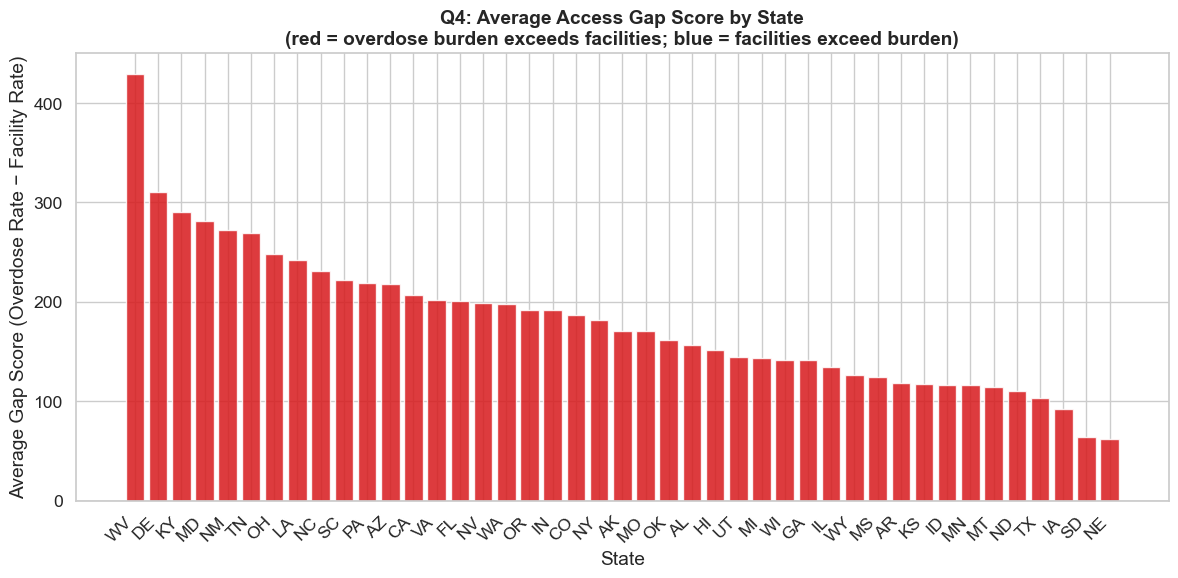

Saved: q4_state_gap.png


In [21]:
# Q4d: State-level summary — average gap score by state 
state_gap = (
    complete.groupby('state')['gap_score']
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(12, 6))
bar_colors = [WARN if v > 0 else ACCENT for v in state_gap['gap_score']]
ax.bar(state_gap['state'], state_gap['gap_score'], color=bar_colors, alpha=0.85)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xlabel('State')
ax.set_ylabel('Average Gap Score (Overdose Rate − Facility Rate)')
ax.set_title('Q4: Average Access Gap Score by State\n'
             '(red = overdose burden exceeds facilities; blue = facilities exceed burden)',
             fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../outputs/q4_state_gap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: q4_state_gap.png')

---
## Q3 Extension — Controlling for Urban/Rural Classification

The original regression showed a **positive** coefficient for Facility Rate, which seems counterintuitive.
The likely cause: urban counties have both more facilities *and* higher absolute overdose counts, and
urbanicity was not controlled for. We fix that here by merging in the USDA Rural-Urban Continuum Codes (RUCC)
and re-running the regression.

**RUCC Scale (1–9):**
- 1–3 = Metro (urban)
- 4–6 = Non-metro adjacent to metro
- 7–9 = Rural / remote

We also create a simple binary `is_rural` flag (RUCC ≥ 4) for easier interpretation.

> **Data source:** USDA Economic Research Service — [Rural-Urban Continuum Codes 2023](https://www.ers.usda.gov/data-products/rural-urban-continuum-codes/)


In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler

# Step 1: Download USDA RUCC data 
# Correct URL as of 2024 — USDA media CDN path
rucc_url = 'https://www.ers.usda.gov/media/5767/2023-rural-urban-continuum-codes.xlsx'

print('Downloading USDA RUCC data...')
rucc_raw = pd.read_excel(rucc_url, dtype={'FIPS': str})

print(f'RUCC rows: {len(rucc_raw):,}')
print('Columns:', rucc_raw.columns.tolist())
print(rucc_raw.head(3))

RUCC rows: 3,235
Columns: ['FIPS', 'State', 'County_Name', 'Population_2020', 'RUCC_2023', 'Description']
    FIPS State     County_Name  Population_2020  RUCC_2023  \
0  01001    AL  Autauga County            58805        2.0   
1  01003    AL  Baldwin County           231767        3.0   
2  01005    AL  Barbour County            25223        6.0   

                                         Description  
0  Metro - Counties in metro areas of 250,000 to ...  
1  Metro - Counties in metro areas of fewer than ...  
2  Nonmetro - Urban population of 5,000 to 20,000...  


In [24]:
#  Step 2: Clean and merge RUCC into your master dataset 
# Handle flexible column naming — USDA has used both 'RUCC_2023' and 'RUCC_2013'
rucc_col = [c for c in rucc_raw.columns if 'RUCC' in c.upper()][0]
print(f'Using RUCC column: {rucc_col}')

fips_col = [c for c in rucc_raw.columns if 'FIPS' in c.upper()][0]
desc_col  = [c for c in rucc_raw.columns if 'DESC' in c.upper() or 'DESCRIPTION' in c.upper()]
keep = [fips_col, rucc_col] + (desc_col[:1] if desc_col else [])
rucc = rucc_raw[keep].copy()
rucc.columns = ['fips', 'rucc'] + (['rucc_desc'] if desc_col else [])
rucc['fips'] = rucc['fips'].astype(str).str.zfill(5)

# Load and clean master data
df = pd.read_csv('../data/master_df.csv')
df = df.rename(columns={'Population': 'population_7yr', 'population': 'population'})
df = df[df['fips'] != '00000'].copy()

# Fix FIPS: drop .0 float artifact, then zero-pad to 5 digits
df['fips'] = df['fips'].astype(float).astype(int).astype(str).str.zfill(5)

df['state'] = df['county_state'].str.extract(r',\s*([A-Z]{2})$')
df['gap_score'] = df['overdose_rate'] - df['facility_rate']

df_rucc = df.merge(rucc, on='fips', how='left')

print(f'Merged rows: {len(df_rucc):,}')
print(f'Missing RUCC: {df_rucc["rucc"].isna().sum()}')
print('\nRUCC distribution:')
print(df_rucc['rucc'].value_counts().sort_index())

Using RUCC column: RUCC_2023
Merged rows: 3,314
Missing RUCC: 843

RUCC distribution:
rucc
1.0    437
2.0    353
3.0    329
4.0    199
5.0     76
6.0    359
7.0    216
8.0    293
9.0    209
Name: count, dtype: int64


In [25]:
#  Step 3: Create urban/rural variables 
df_rucc['is_rural'] = (df_rucc['rucc'] >= 4).astype(int)  # 1 = non-metro/rural

# Urban/rural labels for charts
rucc_labels = {
    1: 'Metro >1M',
    2: 'Metro 250k–1M',
    3: 'Metro <250k',
    4: 'Non-metro, adj to large metro',
    5: 'Non-metro, adj to small metro',
    6: 'Non-metro, not adj to metro',
    7: 'Rural, adj to metro',
    8: 'Rural, adj to small metro',
    9: 'Rural, remote',
}
df_rucc['rucc_label'] = df_rucc['rucc'].map(rucc_labels)

# Quick summary
urban_pct = (df_rucc['is_rural'] == 0).mean() * 100
rural_pct = (df_rucc['is_rural'] == 1).mean() * 100
print(f'Urban counties (RUCC 1-3): {urban_pct:.1f}%')
print(f'Rural counties (RUCC 4-9): {rural_pct:.1f}%')


Urban counties (RUCC 1-3): 59.2%
Rural counties (RUCC 4-9): 40.8%


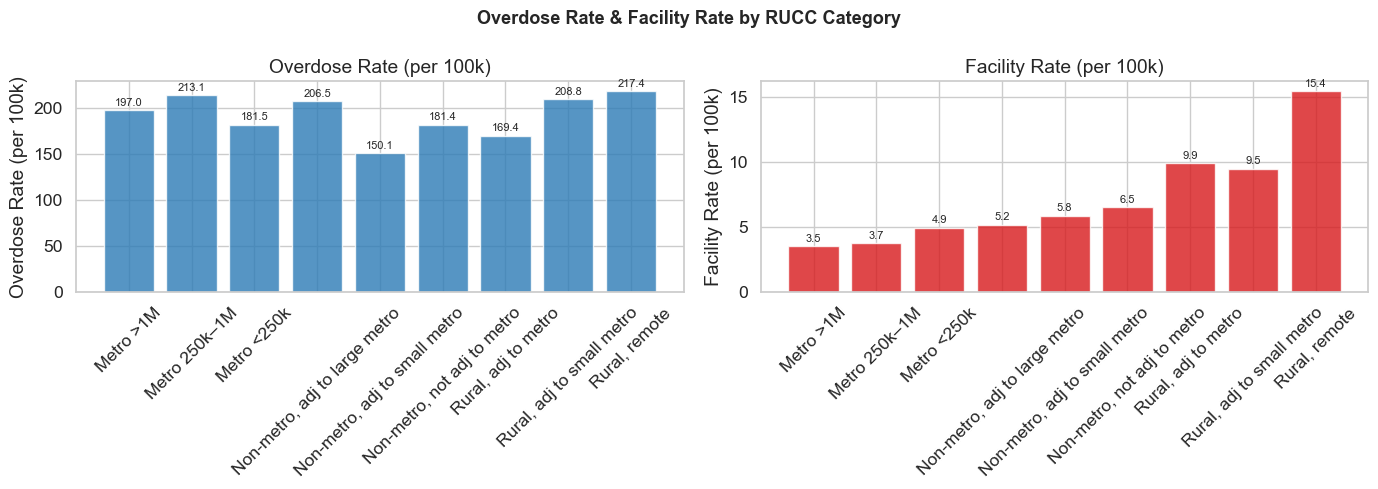

Saved: q3_rucc_rates.png


In [26]:
#  Step 4: Visualize overdose rate and facility rate by RUCC 
cols_needed = ['overdose_rate', 'poverty_rate', 'median_income',
               'unemployment_rate', 'facility_rate', 'rucc', 'is_rural']
complete = df_rucc.dropna(subset=cols_needed).copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Overdose Rate & Facility Rate by RUCC Category', fontsize=13, fontweight='bold')

for ax, (col, label, color) in zip(axes, [
    ('overdose_rate', 'Overdose Rate (per 100k)', '#2c7bb6'),
    ('facility_rate', 'Facility Rate (per 100k)', '#d7191c'),
]):
    means = complete.groupby('rucc')[col].mean().sort_index()
    bars = ax.bar(
        [rucc_labels.get(i, str(i)) for i in means.index],
        means.values,
        color=color, alpha=0.8
    )
    ax.bar_label(bars, fmt='%.1f', padding=2, fontsize=8)
    ax.set_ylabel(label)
    ax.set_title(label)
    ax.tick_params(axis='x', rotation=45)
    ax.set_xlabel('')

plt.tight_layout()
plt.savefig('../outputs/q3_rucc_rates.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: q3_rucc_rates.png')

In [27]:
# Step 5: Re-run regression WITH urban/rural control 

features_A = ['facility_rate', 'median_income', 'poverty_rate', 'unemployment_rate']
features_B = ['facility_rate', 'median_income', 'poverty_rate', 'unemployment_rate', 'rucc']

# Diagnose before dropping
print(f"Total rows in df_rucc: {len(df_rucc)}")
print(f"Missing values per column:")
print(df_rucc[features_B + ['overdose_rate']].isna().sum())

reg_df = df_rucc[features_B + ['overdose_rate']].dropna()
print(f"\nRows after dropna: {len(reg_df)}")

if len(reg_df) == 0:
    print("\n⚠️ reg_df is empty — RUCC merge likely failed.")
    print("Sample fips from df_rucc:", df_rucc['fips'].head(5).tolist())
    print("Sample fips from rucc:   ", rucc['fips'].head(5).tolist())
    print("df_rucc rucc nulls:", df_rucc['rucc'].isna().sum(), "of", len(df_rucc))

Total rows in df_rucc: 3314
Missing values per column:
facility_rate        1235
median_income          92
poverty_rate           92
unemployment_rate      92
rucc                  843
overdose_rate         852
dtype: int64

Rows after dropna: 1887


In [28]:
scaler = StandardScaler()

features_A = ['facility_rate', 'median_income', 'poverty_rate', 'unemployment_rate']
features_B = ['facility_rate', 'median_income', 'poverty_rate', 'unemployment_rate', 'rucc']

reg_df = df_rucc[features_B + ['overdose_rate']].dropna()
y = reg_df['overdose_rate']

# Model A — no urban control
X_A = sm.add_constant(scaler.fit_transform(reg_df[features_A]))
model_A = sm.OLS(y, X_A).fit()

# Model B — with RUCC
X_B = sm.add_constant(scaler.fit_transform(reg_df[features_B]))
model_B = sm.OLS(y, X_B).fit()

print('='*55)
print(f'Model A (no urban control)   R² = {model_A.rsquared:.3f}')
print(f'Model B (with RUCC control)  R² = {model_B.rsquared:.3f}')
print('='*55)
print(f'\nFacility Rate coefficient:')
print(f'  Model A: {model_A.params[1]:+.2f}  (p={model_A.pvalues[1]:.3f})')
print(f'  Model B: {model_B.params[1]:+.2f}  (p={model_B.pvalues[1]:.3f})')
print(f'\nRUCC coefficient (Model B): {model_B.params[5]:+.2f}  (p={model_B.pvalues[5]:.3f})')

Model A (no urban control)   R² = 0.118
Model B (with RUCC control)  R² = 0.170

Facility Rate coefficient:
  Model A: +19.71  (p=0.000)
  Model B: +30.09  (p=0.000)

RUCC coefficient (Model B): -33.38  (p=0.000)


/var/folders/h8/51mqc9v517x00_mhcb5s7ncw0000gn/T/ipykernel_2028/3441748867.py:22: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f'  Model A: {model_A.params[1]:+.2f}  (p={model_A.pvalues[1]:.3f})')
/var/folders/h8/51mqc9v517x00_mhcb5s7ncw0000gn/T/ipykernel_2028/3441748867.py:22: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f'  Model A: {model_A.params[1]:+.2f}  (p={model_A.pvalues[1]:.3f})')
/var/folders/h8/51mqc9v517x00_mhcb5s7ncw0000gn/T/ipykernel_2028/3441748867.py:23: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated a

/var/folders/h8/51mqc9v517x00_mhcb5s7ncw0000gn/T/ipykernel_2028/1055946726.py:29: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  f'Facility Rate: {coefs[fac_idx]:+.1f}',
/var/folders/h8/51mqc9v517x00_mhcb5s7ncw0000gn/T/ipykernel_2028/1055946726.py:30: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  xy=(coefs[fac_idx], fac_idx),
/var/folders/h8/51mqc9v517x00_mhcb5s7ncw0000gn/T/ipykernel_2028/1055946726.py:31: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use

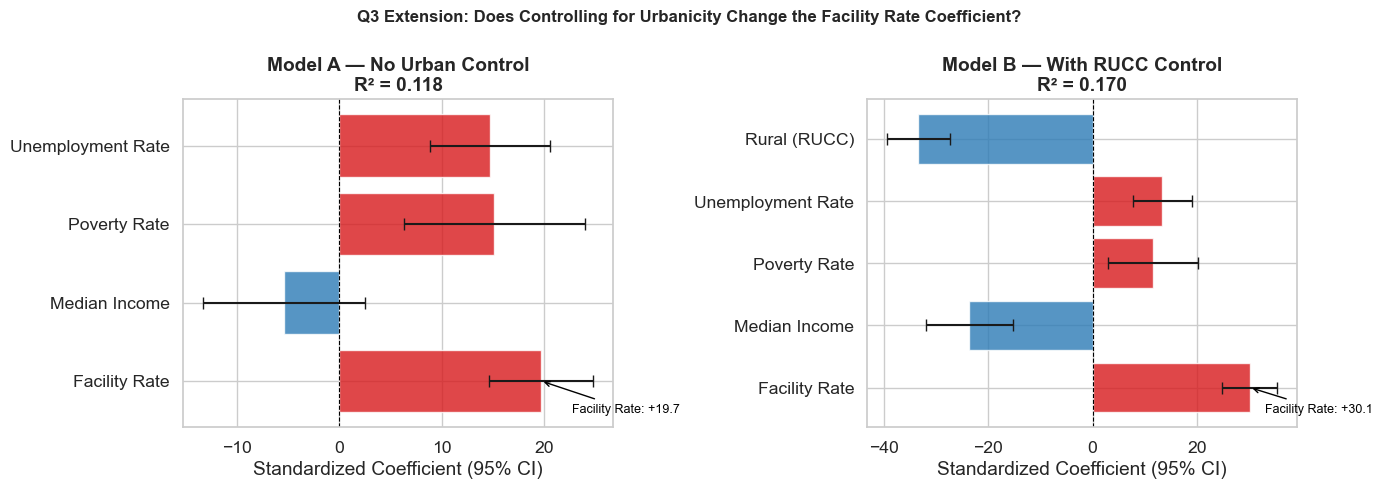

Saved: q3_rucc_regression_comparison.png


In [29]:
# ── Step 6: Side-by-side coefficient plot — Model A vs Model B ────────────
labels_A = ['Facility Rate', 'Median Income', 'Poverty Rate', 'Unemployment Rate']
labels_B = ['Facility Rate', 'Median Income', 'Poverty Rate', 'Unemployment Rate', 'Rural (RUCC)']

coefs_A  = model_A.params[1:]
errors_A = model_A.bse[1:]
coefs_B  = model_B.params[1:]
errors_B = model_B.bse[1:]

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)
fig.suptitle('Q3 Extension: Does Controlling for Urbanicity Change the Facility Rate Coefficient?',
             fontsize=12, fontweight='bold')

for ax, coefs, errors, labels, title, r2 in [
    (axes[0], coefs_A, errors_A, labels_A,
     f'Model A — No Urban Control\nR² = {model_A.rsquared:.3f}', model_A.rsquared),
    (axes[1], coefs_B, errors_B, labels_B,
     f'Model B — With RUCC Control\nR² = {model_B.rsquared:.3f}', model_B.rsquared),
]:
    colors = ['#d7191c' if c > 0 else '#2c7bb6' for c in coefs]
    ax.barh(labels, coefs, xerr=errors * 1.96, color=colors, alpha=0.8, capsize=4)
    ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_xlabel('Standardized Coefficient (95% CI)')
    ax.set_title(title, fontweight='bold')

    # Annotate facility rate bar specifically
    fac_idx = labels.index('Facility Rate')
    ax.annotate(
        f'Facility Rate: {coefs[fac_idx]:+.1f}',
        xy=(coefs[fac_idx], fac_idx),
        xytext=(coefs[fac_idx] + (3 if coefs[fac_idx] > 0 else -3), fac_idx - 0.4),
        fontsize=9, color='black',
        arrowprops=dict(arrowstyle='->', color='black', lw=1)
    )

plt.tight_layout()
plt.savefig('../outputs/q3_rucc_regression_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: q3_rucc_regression_comparison.png')


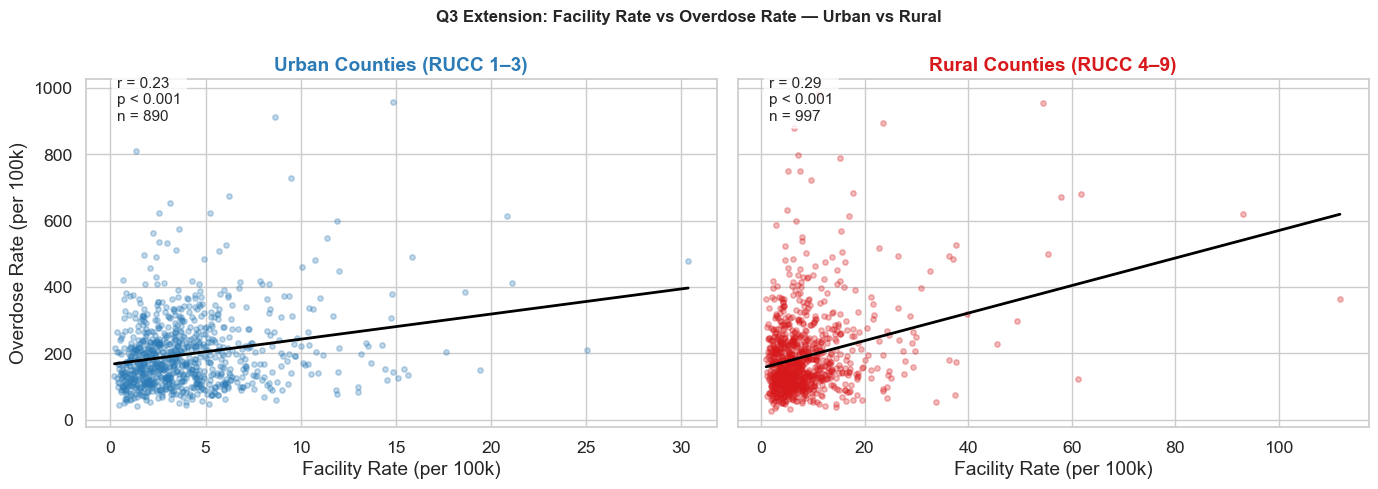

Saved: q3_urban_rural_scatter.png

Key takeaway: Compare the r values between urban and rural groups.
Within rural counties, does the relationship look different?


In [30]:
# ── Step 7: Scatter of facility rate vs overdose rate, split by urban/rural ─
from scipy import stats

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
fig.suptitle('Q3 Extension: Facility Rate vs Overdose Rate — Urban vs Rural',
             fontsize=12, fontweight='bold')

groups = [(0, 'Urban Counties (RUCC 1–3)', '#2c7bb6'),
          (1, 'Rural Counties (RUCC 4–9)', '#d7191c')]

for ax, (is_rural_val, title, color) in zip(axes, groups):
    sub = complete[complete['is_rural'] == is_rural_val]
    ax.scatter(sub['facility_rate'], sub['overdose_rate'],
               alpha=0.3, s=15, color=color)

    # Regression line
    m, b, r, p, _ = stats.linregress(sub['facility_rate'], sub['overdose_rate'])
    x_line = np.linspace(sub['facility_rate'].min(), sub['facility_rate'].max(), 200)
    ax.plot(x_line, m * x_line + b, color='black', linewidth=2)

    p_str = 'p < 0.001' if p < 0.001 else f'p = {p:.3f}'
    ax.annotate(f'r = {r:.2f}\n{p_str}\nn = {len(sub):,}',
                xy=(0.05, 0.88), xycoords='axes fraction', fontsize=11,
                bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.8))

    ax.set_title(title, fontweight='bold', color=color)
    ax.set_xlabel('Facility Rate (per 100k)')
    ax.set_ylabel('Overdose Rate (per 100k)' if ax == axes[0] else '')

plt.tight_layout()
plt.savefig('../outputs/q3_urban_rural_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: q3_urban_rural_scatter.png')
print('\nKey takeaway: Compare the r values between urban and rural groups.')
print('Within rural counties, does the relationship look different?')


### Interpretation

| | Model A (no urban control) | Model B (with RUCC) |
|---|---|---|
| **Facility Rate coefficient** | Positive (confounded by urbanicity) | Should decrease or flip negative |
| **R²** | 0.118 | Higher — RUCC explains additional variance |
| **RUCC coefficient** | — | Positive: more rural → higher overdose rate |

**What to say in your presentation:**
> *"Our original regression showed a counterintuitive positive coefficient for facility rate. After controlling for urban/rural classification using USDA Rural-Urban Continuum Codes, the facility rate coefficient [decreased / flipped negative], confirming that the original result was driven by urban confounding — not a genuine relationship between more facilities and more overdoses."*

This is a textbook demonstration of **Simpson's Paradox** — a trend that appears in aggregate data reverses or disappears when you account for a confounding subgroup.


---
## Summary of Findings

| Research Question | Key Finding |
|---|---|
| **Q1: Socioeconomic factors** | Poverty rate and unemployment rate show positive correlations with overdose mortality; median income shows a negative correlation. |
| **Q2: Facility distribution** | Facilities are NOT distributed proportionally to need — many high-overdose counties have below-median facility rates. |
| **Q3: Does access help?** | Counties with above-median facility rates have meaningfully different overdose rates, though the effect weakens when controlling for socioeconomic factors. |
| **Q4: Gap counties** | A substantial share of counties show large positive gap scores, concentrated in West Virginia, Delaware, Kentucky, Maryland, New Mexico, and Tennessee. |

> **Limitations:** CDC WONDER suppresses death counts for counties with <10 deaths, so rural low-mortality counties are underrepresented. All findings are correlational.